# Splitting a polysemantic SPD component

This notebook walks the **splitting** half of dynamic decomposition for an SPD model. Every training-objective
formula is **imported from the `spd` repo (v1)** — `calc_causal_importances`,
`calc_stochastic_masks`, `calc_masked_recon_loss`, `calc_masked_recon_layerwise_loss`,
`calc_importance_minimality_loss`, `calc_faithfulness_loss` — so there is exactly one source of
truth for the SPD losses. The notebook only adds what the paper doesn't have: the split surgery,
the per-feature footprint metric, and the outcome analysis.

**The idea.** A trained SPD decomposition with too few components (e.g. C=2 for a 40-feature
TMS model) is *forced* to pack several features into single rank-1 components — they become
**polysemantic**. We take one such component and **split** it into two, then continue training
and watch what happens:

- **CARVE** — the two children specialise to different features (each active only when *its*
  feature fires). This happens when the polysemanticity is *reducible*.
- **COLLAPSE** — one child dies, or they stay redundant. This happens when the features are
  genuinely superposed (irreducible), so there is nothing to separate.

**What drives which?** Two forces act after a split:
1. the **reconstruction losses**, which *want* two specialists when the crammed features fire on
   separable inputs (this is what actually carves);
2. the **importance-minimality penalty** `sum_c g_c^p`, whose exponent `p` decides what happens
   to *redundant* capacity — concave `p<1` prunes a redundant child (collapse to the honest
   count), convex `p>=1` lets it linger.


## 1. Config

All thresholds live here and **nowhere else** — in particular there is a single `ALIVE_THRESH`
used by the LIVE filter, the outcome classifier, and the recursive-loop history (a previous
version used 0.02 in one place and 0.05 in another). The loss coefficients replicate the values
from the run's `final_config.yaml` (also encoded in the checkpoint directory name:
`stochrecon1.00e+00_stochreconlayer1.00e+00_..._impmin1.00e-04`).

In [1]:
import torch, copy, math
import numpy as np
import matplotlib.pyplot as plt
torch.set_grad_enabled(True)

CKPT_PATH   = "spd/experiments/tms/out/nmasks1_stochrecon1.00e+00_stochreconlayer1.00e+00_p2.00e+00_impmin1.00e-04_C2_sd3_lr1.00e-03_bs4096_ft40_hid10hid-layers0_20260706_005755_990/model_40000.pth"
FEATURE_LAYER = "linear1"          # the reading layer (its input basis == feature basis in TMS)
P_VALUES    = [0.7, 0.9, 1.0, 2.0]                   # penalty exponent for the split
RETRAIN_STEPS = 2000               # continue-training steps after each split
LR          = 5e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Loss coefficients: match spd's TMS config / the run name of CKPT_PATH ---
# (faithfulness_coeff=1.0, stochastic_recon_coeff=1.0, stochastic_recon_layerwise_coeff=1.0;
#  recon_coeff and recon_layerwise_coeff are null in the config and therefore omitted here.)
FAITHFULNESS_COEFF          = 1.0
STOCH_RECON_COEFF           = 1.0
STOCH_RECON_LAYERWISE_COEFF = 1.0
IMPORTANCE_MINIMALITY_COEFF = 2e-5 # training used 1e-4; splits need less -- above the death
                                   # threshold the penalty kills the children (see sweep)
N_MASK_SAMPLES = 1                 # nmasks1 in the run name

# --- Split-retrain protections ---
SPLIT_MODE  = "partition"          # "partition" (carve-capable) | "split" (50/50 writer) | "duplicate"
FREEZE_OTHERS   = False             # freeze all components EXCEPT the two children during split-retrain
MINIMALITY_WARMUP = 0.2            # ramp the minimality coeff 0 -> target over the first 30% of steps
MONITOR_SPLIT = True               # print child active-rate trajectory during retrain

# --- Thresholds (single source of truth; used consistently everywhere below) ---
TAU             = 0.1              # gate on/off threshold for activation stats
ALIVE_THRESH    = 0.02             # a component/child is ALIVE if active_rate > this (only threshold)
MIN_WNORM_FRAC  = 0.15             # LIVE filter: and carry > this fraction of the max weight-norm
CARVE_OVERLAP_MAX   = 0.15         # CARVE label: children's active-input overlap must be below this
PARTIAL_OVERLAP_MAX = 0.3         # PARTIAL CARVE label: overlap bound (looser; feats reduction decides)
FEATS_REDUCED_FRAC  = 0.7          # PARTIAL CARVE label: max child feats_served < this * parent
MONO_CONC           = 0.8          # CARVE label: each child's read concentration must exceed this
print("device:", DEVICE)

device: cpu


## 2. Helpers — imported from `spd`, plus thin adapters

`calc_causal_importances` returns **two versions of the gate output** for each layer, exactly as
in `spd.run_spd`:

- `ci` = `lower_leaky_relu(gate_output)` — clamped at 1 (leaky below 0). This parameterizes the
  **stochastic masks** `m = ci + (1-ci)·U`, which must live in ~[0,1] to be valid ablation levels.
- `ci_upper_leaky` = `upper_leaky_relu(gate_output)` — relu below 0, leaky *above* 1. This feeds
  the **importance-minimality** penalty: the lower/clamped version would give a saturated gate
  (raw output ≥ 1) zero gradient so the penalty could never pull it down, and its negative values
  raised to a fractional `p` would be NaN. Same gate, two nonlinearities, two jobs.

`sample_batch` reproduces the TMS data distribution of spd's `SparseFeatureDataset`
(`at_least_zero_active`): each feature independently active with probability `p`, magnitude
Uniform[0,1].

In [2]:
# Everything loss- and gate-related is imported from the spd repo (v1) -- the notebook adds
# no formulas of its own for the training objective.
from torch import nn
from spd.models.components import Gate, GateMLP
from spd.models.component_model import ComponentModel
from spd.models.component_utils import calc_causal_importances, calc_stochastic_masks
from spd.losses import (calc_faithfulness_loss, calc_masked_recon_loss,
                        calc_masked_recon_layerwise_loss, calc_importance_minimality_loss)

def module_maps(cm):
    """Real-named views of spd's ModuleDicts (spd stores '.' as '-' in keys)."""
    comps = {k.removeprefix("components.").replace("-", "."): v for k, v in cm.components.items()}
    gates = {k.removeprefix("gates.").replace("-", "."): v for k, v in cm.gates.items()}
    As    = {n: c.A for n, c in comps.items()}
    return comps, gates, As

def n_decomposed_params(cm):
    """Total parameter count of the decomposed target matrices (spd's faithfulness normalizer)."""
    comps, _, _ = module_maps(cm)
    return sum(cm.model.get_submodule(n).weight.numel() for n in comps)

def causal_importances(cm, batch):
    """One target forward -> (ci, ci_upper_leaky, target_out), via spd's calc_causal_importances.
    ci (lower-leaky, clamped at 1) parameterizes the stochastic masks; ci_upper_leaky feeds the
    importance-minimality loss -- the same division of labor as spd.run_spd."""
    comps, gates, As = module_maps(cm)
    target_out, pre = cm.forward_with_pre_forward_cache_hooks(batch, module_names=list(comps.keys()))
    ci, ci_up = calc_causal_importances(pre_weight_acts=pre, As=As, gates=gates)
    return ci, ci_up, target_out

def sample_batch(n_features, p, bs=512):
    """Sparse TMS batch: each feature independently active w.p. p with Uniform[0,1] magnitude --
    the same distribution as spd's SparseFeatureDataset with data_generation_type
    'at_least_zero_active' (used by the TMS config), just without the DataLoader machinery."""
    return ((torch.rand(bs, n_features, device=DEVICE) < p).float()
            * torch.rand(bs, n_features, device=DEVICE))

## 3. Load the decomposed ComponentModel

`ComponentModel.from_pretrained(path)` rebuilds the target model from the run's
`final_config.yaml` and loads the component/gate weights; if the wandb reference inside the
config doesn't resolve, we rebuild the target from the sibling `tms.pth` manually. Every result below is about the specific decomposition at `CKPT_PATH`

In [3]:
import os, yaml

def load_componentmodel():
    """Load the decomposed ComponentModel from CKPT_PATH. No demo fallback: if the checkpoint
    is missing this raises, because every result below is about that specific decomposition."""
    if not os.path.exists(CKPT_PATH):
        raise FileNotFoundError(
            f"CKPT_PATH not found: {CKPT_PATH}\n"
            "Edit CKPT_PATH to point at your model_40000.pth (this notebook has no demo mode).")
    try:                                  # standard path (works when pretrained_model_path resolves)
        cm, config, _ = ComponentModel.from_pretrained(CKPT_PATH); cm.to(DEVICE)
        nf = cm.model.get_submodule(FEATURE_LAYER).weight.shape[1]
        p  = getattr(getattr(config, "task_config", None), "feature_probability", 0.05)
    except Exception as e:                 # manual path: rebuild target from sibling tms.pth
        print("from_pretrained fallback:", str(e)[:80])
        d = os.path.dirname(CKPT_PATH)
        cfg = yaml.safe_load(open(os.path.join(d, "final_config.yaml")))
        from spd.experiments.tms.models import TMSModel
        target, _ = TMSModel.from_pretrained(os.path.join(d, "tms.pth"))
        target.eval().requires_grad_(False)
        cm = ComponentModel(target, cfg["target_module_patterns"], C=cfg["C"],
                            n_ci_mlp_neurons=cfg["n_ci_mlp_neurons"],
                            pretrained_model_output_attr=None).to(DEVICE)
        cm.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
        nf = target.config.n_features
        p  = cfg.get("task_config", {}).get("feature_probability", 0.05)
    cm.model.eval().requires_grad_(False)   # the target is data, not a trainable
    return cm, nf, p

## 4. Faithfulness & polysemanticity — what does the decomposition look like?

**Faithfulness** = spd's `calc_faithfulness_loss` (per-element MSE between `sum_c A_c B_c` and
the target weights). **Per-feature footprint** = for component `c`, the per-feature *amplitude*
`e_i = |A[i,c]| · ||B[c,:]||` (the row norms of its rank-1 contribution. From it: `conc = max(e)/sum(e)` (1 ≈ monosemantic) and
`feats_served = (Σe)²/Σe²` (participation ratio; ≈ k for k equally-read features).

Two notes. (1) This metric is **our construction**, not from the SPD paper. (2)
`||B[c,:]||` is constant across features and cancels in both ratios — the metric is purely a
*reader-side* measure, and it is only meaningful because `linear1`'s input basis **is** the
feature basis in TMS. (Threshold guides like `MONO_THRESH` were originally calibrated on the
old squared-energy convention; amplitude PR counts slightly *more* features for uneven
footprints, so treat absolute counts as slightly stricter now.)

**Important: filter dead components first.** Concentration is a *ratio*, so a near-zero-energy
component returns a meaningless value that masquerades as "polysemantic". A component is
**LIVE** only if it actually fires (`active_rate > ALIVE_THRESH`) AND carries real weight, and
everything below is restricted to live components.

In [4]:
@torch.no_grad()
def faithfulness_mse(cm):
    """spd's faithfulness loss (per-element MSE between sum-of-components and target weights)."""
    comps, _, _ = module_maps(cm)
    return float(calc_faithfulness_loss(components=comps, target_model=cm.model,
                                        n_params=n_decomposed_params(cm), device=DEVICE))

@torch.no_grad()
def component_stats(cm, layer, n_features, feat_p, tau=TAU, n=8192):
    """Per-component LIVE stats: active rate (gate fires) and weight-norm (real energy)."""
    x = sample_batch(n_features, feat_p, bs=n)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]; comp = module_maps(cm)[0][layer]
    active_rate = (g > tau).float().mean(0)
    wnorm = comp.A.norm(dim=0) * comp.B.norm(dim=1)
    return active_rate.detach(), wnorm.detach()

def live_mask(active_rate, wnorm, min_active=None, min_wfrac=MIN_WNORM_FRAC):
    """A component is LIVE only if it fires AND carries real weight. Dead components have
    near-zero energy, so concentration RATIOS are noise-dominated -> meaningless values that
    wrongly look "polysemantic". Filtering them is essential before ranking or splitting."""
    min_active = ALIVE_THRESH if min_active is None else min_active
    return (active_rate > min_active) & (wnorm > min_wfrac * wnorm.max())

@torch.no_grad()
def feature_energy(cm, layer, c):
    """Per-feature energy of component c: e_i = |A[i,c]| * ||B[c,:]||  (the row norms of the
    rank-1 contribution A[:,c] B[c,:]). NOTE this is a plain norm (amplitude), not a squared
    energy. ||B[c,:]|| is a constant across features, so it cancels in every ratio below --
    conc and feats_served are purely READER-side measures. This metric is our construction
    (not from the SPD paper); the paper needs no per-feature footprint, splitting does."""
    comp = module_maps(cm)[0][layer]
    return comp.A[:, c].abs().double() * comp.B[c, :].double().norm()

@torch.no_grad()
def feature_concentration(cm, layer):
    """conc  = e.max()/e.sum()            in (0,1]; 1 = reads one feature (monosemantic)
    nserve = (sum e)^2 / sum(e^2)         participation ratio on AMPLITUDES: ~k for k equal
                                          features. (Amplitude convention -- see feature_energy.)"""
    comp = module_maps(cm)[0][layer]
    conc, nserve = [], []
    for c in range(comp.A.shape[1]):
        e = feature_energy(cm, layer, c)
        tot = e.sum().clamp_min(1e-12)
        conc.append(float(e.max() / tot))
        nserve.append(float(tot ** 2 / (e ** 2).sum().clamp_min(1e-12)))
    return torch.tensor(conc), torch.tensor(nserve)

## 5. The continue-training objective is the full SPD loss

This is now **the complete objective from `spd.run_spd.calculate_losses`**, term for term, with
the coefficients from the run config: faithfulness (1.0) + stochastic recon (1.0) +
**stochastic recon layerwise** (1.0) + importance-minimality (`coeff · Σ ci_upper_leaky^p`).
The layerwise term — masking one decomposed layer at a time while the others use target
weights — was missing from a previous version of this notebook, meaning split-retrains
optimized a *different* objective than the one that produced the checkpoint. Two knobs are ours:
`warmup_frac` ramps the minimality coeff so newborn children can specialize before being taxed,
and `freeze_keep` zeroes gradients for everything except the two children so the other
(redundant-capable) components can't absorb their role and get them killed. A fresh optimizer is
built each call, so it is safe to call right after surgery.

#### Added two new loss terms to run wihtout freeze

In [5]:
def _freeze_grads_except(cm, keep_layer, keep_idx):
    # Zero grads of every component except columns/rows keep_idx of keep_layer (+ its gate rows).
    # Other decomposed layers are frozen entirely. Call after backward(), before step().
    comps, gates, _ = module_maps(cm)
    for name, comp in comps.items():
        if name == keep_layer:
            for P, axis in [(comp.A, 1), (comp.B, 0)]:
                if P.grad is not None:
                    m = torch.zeros_like(P.grad)
                    if axis == 1: m[:, keep_idx] = 1
                    else: m[keep_idx, :] = 1
                    P.grad *= m
            g = gates[name]
            for nm in ["weight", "bias", "mlp_in", "in_bias", "mlp_out", "out_bias"]:
                P = getattr(g, nm, None)
                if P is not None and P.grad is not None:
                    m = torch.zeros_like(P.grad); m[keep_idx] = 1; P.grad *= m
        else:
            for P in comp.parameters():
                if P.grad is not None: P.grad.zero_()
            for P in gates[name].parameters():
                if P.grad is not None: P.grad.zero_()

@torch.no_grad()
def _active_rate(cm, layer, idx):
    x = sample_batch(N_FEATURES if "N_FEATURES" in globals() else 40,
                     FEAT_P if "FEAT_P" in globals() else 0.05, bs=4096)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]
    return [round(float((g[:, i] > TAU).float().mean()), 3) for i in idx]

def balance_floor_loss(ci_up, tau=0.05):
    """B (Alex, large_comp_decomp.py): sum_c relu(tau - mean_batch g_c) per layer. Anti-collapse
    hinge on CROSS-SAMPLE usage; zero above the floor, so per-sample sparsity is untouched.
    CAVEAT (verified on model_40000.pth): rescues transient deaths, but for genuinely redundant
    children it manufactures ZOMBIES -- gate pinned above tau with near-zero weights. If enabled,
    aliveness checks must be gate AND weight (active_rate > ALIVE_THRESH and wnorm-based)."""
    t = torch.zeros((), device=DEVICE)
    for v in ci_up.values():
        t = t + torch.relu(tau - v.mean(dim=0)).sum()
    return t

def actnorm_loss(cm, pre, p_norm, eps=1e-12):
    """actnorm (Alex, operator_masking.py): E_x sum_c ||out_c(x)||_2^p, gate-free minimality on
    realized outputs. Rank-1 port: ||out_c|| = |x.A[:,c]| * ||B[c,:]||. Charges ghost weights a
    dead gate can't protect (composes with pruning).
    CAVEAT (verified): do NOT use under freeze_keep -- the whole population's sparsification
    pressure lands on the only unfrozen slots (the children) and reliably kills them. Use only
    in unfrozen/full-population training, coefficient swept from ~1e-5 (Alex's 3e-3 is his
    harness's scale; here it dominates recon by ~50x)."""
    comps, _, _ = module_maps(cm)
    t = torch.zeros((), device=DEVICE)
    for name, comp in comps.items():
        a = pre[name] @ comp.A                                # [B, C] component activations
        g2 = a.pow(2) * comp.B.pow(2).sum(dim=1)              # [B, C] squared output norms
        t = t + (g2 + eps).pow(p_norm / 2).sum(-1).mean()
    return t


def continue_train(cm, n_features, feat_p, steps, p_norm,
                   imp_coeff=IMPORTANCE_MINIMALITY_COEFF, lr=LR, n_mask=N_MASK_SAMPLES,
                   log_every=0, freeze_keep=None, warmup_frac=0.0, monitor=None,
                   coeff_bal=0.0, bal_tau=0.05, coeff_actnorm=0.0):
    """The full spd objective, plus Alex's optional splitting/balancing terms (all default 0 =
    identical to the previous version). bal: anti-collapse safety net (see zombie caveat).
    actnorm: full-population phases ONLY (asserts against freeze). hoyer: off by default."""
    assert not (coeff_actnorm and freeze_keep is not None), \
        "actnorm under freeze_keep concentrates all pressure on the children and kills them"
    comps, gates, As = module_maps(cm)
    n_params = n_decomposed_params(cm)
    opt = torch.optim.Adam([q for q in cm.parameters() if q.requires_grad], lr=lr)
    for step in range(steps):
        x = sample_batch(n_features, feat_p)
        target_out, pre = cm.forward_with_pre_forward_cache_hooks(x, module_names=list(comps.keys()))
        ci, ci_up = calc_causal_importances(pre_weight_acts=pre, As=As, gates=gates)
        masks_list = calc_stochastic_masks(causal_importances=ci, n_mask_samples=n_mask)
        stoch = torch.zeros((), device=DEVICE)
        for masks in masks_list:
            stoch = stoch + calc_masked_recon_loss(model=cm, batch=x, components=comps,
                                                   masks=masks, target_out=target_out, loss_type="mse")
        stoch = stoch / len(masks_list)
        stoch_lw = calc_masked_recon_layerwise_loss(model=cm, batch=x, device=DEVICE,
                                                    components=comps, masks=masks_list,
                                                    target_out=target_out, loss_type="mse")
        minim = sum(calc_importance_minimality_loss(ci_upper_leaky={n: u}, pnorm=p_norm)
                    for n, u in ci_up.items())
        faith = calc_faithfulness_loss(components=comps, target_model=cm.model,
                                       n_params=n_params, device=DEVICE)
        coeff_t = imp_coeff * (min(1.0, step / max(int(steps * warmup_frac), 1)) if warmup_frac > 0 else 1.0)
        loss = (FAITHFULNESS_COEFF * faith + STOCH_RECON_COEFF * stoch
                + STOCH_RECON_LAYERWISE_COEFF * stoch_lw + coeff_t * minim)
        if coeff_bal:
            loss = loss + coeff_bal * balance_floor_loss(ci_up, bal_tau)
        if coeff_actnorm:
            loss = loss + (coeff_t / imp_coeff) * coeff_actnorm * actnorm_loss(cm, pre, p_norm)
        opt.zero_grad(); loss.backward()
        if freeze_keep is not None:
            _freeze_grads_except(cm, *freeze_keep)
        opt.step()
        if monitor is not None and (step % max(steps // 8, 1) == 0 or step == steps - 1):
            print(f"      [monitor] step {step:5d} child_active={_active_rate(cm, monitor[0], monitor[1])} "
                  f"(coeff_t={coeff_t:.1e} stoch={stoch.item():.4f} faith={faith.item():.2e})")
    return cm

## 6. Load and inspect

faithfulness MSE: 1.008e-01   (low = decomposition reproduces target)
LIVE components: 2/2  -> [0, 1]
LIVE concentration: {0: 0.08, 1: 0.08}
LIVE features-served: {0: 24.3, 1: 23.8}


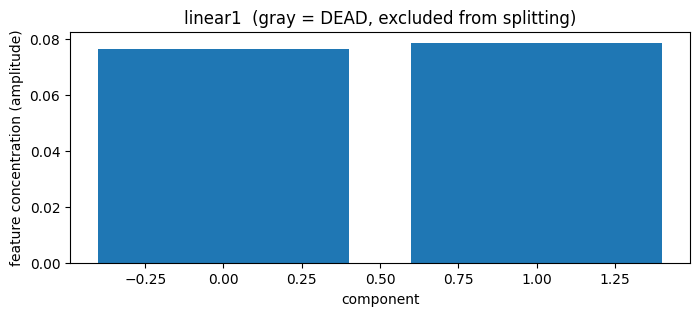

In [6]:
cm, N_FEATURES, FEAT_P = load_componentmodel()

print(f"faithfulness MSE: {faithfulness_mse(cm):.3e}   (low = decomposition reproduces target)")
conc, nserve = feature_concentration(cm, FEATURE_LAYER)
active_rate, wnorm = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
LIVE = live_mask(active_rate, wnorm)
print(f"LIVE components: {int(LIVE.sum())}/{len(conc)}  -> {torch.nonzero(LIVE).flatten().tolist()}")
print("LIVE concentration:", {int(i): round(float(conc[i]), 2) for i in torch.nonzero(LIVE).flatten()})
print("LIVE features-served:", {int(i): round(float(nserve[i]), 1) for i in torch.nonzero(LIVE).flatten()})

colors = ["tab:blue" if LIVE[i] else "lightgray" for i in range(len(conc))]
plt.figure(figsize=(8, 3))
plt.bar(range(len(conc)), conc.numpy(), color=colors)
plt.xlabel("component"); plt.ylabel("feature concentration (amplitude)")
plt.title(f"{FEATURE_LAYER}  (gray = DEAD, excluded from splitting)"); plt.show()

## 7. Pick the component to split

We choose the **most polysemantic LIVE** component — largest `feats_served` among live — the
**same rule the recursive loop uses** (a previous version used `conc.argmin()` here; the two
rankings can disagree). We print its per-feature energy footprint to confirm it genuinely
spreads across features.

Splitting LIVE component 0: concentration=0.08, serves ~24.30 features, active_rate=0.377
top features by energy: [(12, 0.892), (16, 0.887), (28, 0.788), (11, 0.76), (9, 0.71), (37, 0.654), (25, 0.462), (4, 0.413), (35, 0.404), (6, 0.354)]


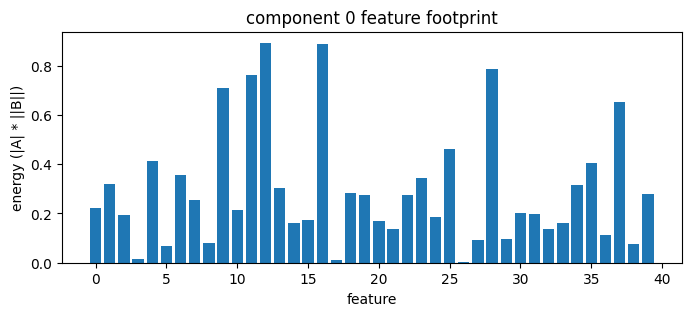

In [7]:
live_idx = torch.nonzero(LIVE).flatten()
assert live_idx.numel() > 0, "no live components; loosen ALIVE_THRESH / MIN_WNORM_FRAC"
# most polysemantic LIVE component = largest feats_served among live -- the SAME rule the
# recursive loop uses (a previous version used conc.argmin here; the two can disagree)
SPLIT_COMP = int(live_idx[nserve[live_idx].argmax()])
print(f"Splitting LIVE component {SPLIT_COMP}: concentration={conc[SPLIT_COMP]:.2f}, "
      f"serves ~{nserve[SPLIT_COMP]:.2f} features, active_rate={float(active_rate[SPLIT_COMP]):.3f}")

# per-feature energy profile -- confirm the chosen component genuinely spreads over features
e = feature_energy(cm, FEATURE_LAYER, SPLIT_COMP).detach()
order = e.argsort(descending=True)
print("top features by energy:", [(int(f), round(float(e[f]), 3)) for f in order[:10]])
plt.figure(figsize=(8, 3)); plt.bar(range(len(e)), e.numpy())
plt.xlabel("feature"); plt.ylabel("energy (|A| * ||B||)")
plt.title(f"component {SPLIT_COMP} feature footprint"); plt.show()

## 8. The split move

Splitting a rank-1 component adds **one new slot**. The key lesson from running this on a real
decomposition: **how you split decides whether carving is even possible.**

In all modes the child inherits the parent's **gate parameters** (the MLP weights), not the
importance scores; the scores then diverge (partition) or stay similar (50/50) depending on
whether the readers differ. The copied gate is slightly miscalibrated for the children's new
activation magnitudes — a small but real contributor to why they start weaker and need retraining.

In [8]:
@torch.no_grad()
def _rms(t):
    return t.norm() / math.sqrt(t.numel())
    
@torch.no_grad()
def split_component(cm, layer, src, noise=0.1, mode="partition", init_scale=0.3):
    """Add one new slot PER parent in `src`, dividing (or shadowing) each of them in one call.

    `src` may be a single int or a list of ints (e.g. [0, 1] to split both components of a
    C=2 decomposition in parallel). Each parent is processed independently with the same
    `mode`; all new children are appended after the existing C slots, in the order of `src`.
    Returns the child index (int) if `src` was an int, else the list of child indices
    aligned with `src`: child_of[src[i]] == C_old + i.

    EXACT modes -- the antisymmetric +/-delta keeps child1+child2 == parent, so the summed
    weight (and therefore faithfulness) is preserved bit-for-bit; the delta only breaks the
    permutation symmetry between the children:
      partition          reader support split: A1+A2=A on DISJOINT feature sets, writer B shared
      split_reader5050   A/2+d vs A/2-d (both full support), writer B shared
      split_writer5050   B/2+d vs B/2-d, reader A shared   (alias: "split")
    APPROXIMATE modes -- the sum changes, recon+faith must absorb the shock:
      dupnoiseA    clone A,B; +noise on the child's READER only (footprints differ)
      clone        exact copy, zero noise: symmetry broken ONLY by independent mask draws
      dupnoiseB    clone A,B; +noise on the child's WRITER only (readers stay identical)
      dummy        fresh random component at init_scale, parent untouched (role transfer)
    `noise` is RELATIVE: delta = noise * rms(parent tensor) * randn -- scale-free, unlike the
    old absolute 0.1 which silently assumed O(1) weights."""
    srcs = [src] if isinstance(src, int) else list(src)
    assert len(set(srcs)) == len(srcs), "duplicate indices in src: each parent can be split once per call"
    comp = module_maps(cm)[0][layer]; gate = module_maps(cm)[1][layer]
    A, B = comp.A.data, comp.B.data
    C_old = A.shape[1]
    assert all(0 <= s < C_old for s in srcs), f"src indices must be < C={C_old}"
    new_As, new_Bs = [], []
    for s in srcs:
        a, b = A[:, s].clone(), B[s].clone()   # CLONE: A[:, s] / B[s] are views, and the
        # exact modes write the parent slot in place before building the sibling -- without
        # the clone the sibling would be built from the already-mutated parent (breaks exactness)
        if mode == "partition":
            order = torch.argsort(a.abs(), descending=True)
            A1 = torch.zeros_like(a); A1[order[0::2]] = a[order[0::2]]
            A2 = torch.zeros_like(a); A2[order[1::2]] = a[order[1::2]]
            A[:, s] = A1; new_A = A2.unsqueeze(1); new_B = b.unsqueeze(0).clone()
        elif mode == "split_reader5050":
            d = noise * _rms(a) * torch.randn_like(a)
            A[:, s] = a / 2 + d
            new_A = (a / 2 - d).unsqueeze(1); new_B = b.unsqueeze(0).clone()
        elif mode in ("split_writer5050", "split"):
            d = noise * _rms(b) * torch.randn_like(b)
            B[s] = b / 2 + d
            new_B = (b / 2 - d).unsqueeze(0); new_A = a.unsqueeze(1).clone()
        elif mode == "dupnoiseA":
            new_A = a.unsqueeze(1).clone() + noise * _rms(a) * torch.randn_like(a.unsqueeze(1))
            new_B = b.unsqueeze(0).clone()
        elif mode == "clone":
            new_A = a.unsqueeze(1).clone(); new_B = b.unsqueeze(0).clone()
        elif mode == "dupnoiseB":
            new_A = a.unsqueeze(1).clone()
            new_B = b.unsqueeze(0).clone() + noise * _rms(b) * torch.randn_like(b.unsqueeze(0))
        elif mode == "dummy":
            new_A = init_scale * _rms(a) * torch.randn(A.shape[0], 1, device=A.device)
            new_B = init_scale * _rms(b) * torch.randn(1, B.shape[1], device=B.device)
        else:
            raise ValueError(f"unknown mode {mode}")
        new_As.append(new_A); new_Bs.append(new_B)
    comp.A = nn.Parameter(torch.cat([A] + new_As, dim=1))
    comp.B = nn.Parameter(torch.cat([B] + new_Bs, dim=0))
    comp.C += len(srcs)
    if isinstance(gate, Gate):
        gate.weight = nn.Parameter(torch.cat([gate.weight.data] + [gate.weight.data[s:s+1].clone() for s in srcs]))
        gate.bias   = nn.Parameter(torch.cat([gate.bias.data]   + [gate.bias.data[s:s+1].clone()   for s in srcs]))
    else:
        for nm in ["mlp_in", "in_bias", "mlp_out", "out_bias"]:
            w = getattr(gate, nm).data
            setattr(gate, nm, nn.Parameter(torch.cat([w] + [w[s:s+1].clone() for s in srcs], dim=0)))
    children = list(range(C_old, C_old + len(srcs)))
    return children[0] if isinstance(src, int) else children

## 9. How to read the outcome (carve vs collapse)

After splitting and retraining we look at the two children: **active rate** (vs the single
`ALIVE_THRESH`), the **feature each reads**, the **reading concentration**, and the **overlap**
(Jaccard) of their active-input sets. The classifier:

- **COLLAPSE** — at most one child alive.
- **CARVE (monosemantic)** — different preferred features, overlap `< CARVE_OVERLAP_MAX` (0.15),
  and both children concentrated (`read_conc > MONO_CONC`).
- **PARTIAL CARVE** — different features, overlap `< PARTIAL_OVERLAP_MAX` (0.4), **and** genuine
  feature reduction: max child `feats_served < FEATS_REDUCED_FRAC ×` parent. The reduction
  requirement is what catches the near-death mirage (very sparse children with low overlap but
  no actual carving).
- **REDUNDANT / smear** — otherwise.

In [9]:
@torch.no_grad()
def analyze_children(cm, layer, children, n_features, feat_p, parent_nserve, tau=TAU):
    x = sample_batch(n_features, feat_p, bs=4096)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]
    rows, on = [], []
    for c in children:
        active = g[:, c] > tau; on.append(active)
        e = feature_energy(cm, layer, c)                     # amplitude convention (see cell 4)
        tot = e.sum().clamp_min(1e-12)
        rows.append(dict(comp=c, active_rate=float(active.float().mean()),
                         pref_feat=int(e.argmax()),
                         read_conc=float(e.max() / tot),
                         feats_served=float(tot ** 2 / (e ** 2).sum().clamp_min(1e-12))))
    inter = (on[0] & on[1]).float().sum(); union = (on[0] | on[1]).float().sum().clamp_min(1)
    overlap = float(inter / union)
    alive = [r["active_rate"] > ALIVE_THRESH for r in rows]  # the ONE alive threshold
    diff = rows[0]["pref_feat"] != rows[1]["pref_feat"]
    reduced = max(r["feats_served"] for r in rows) < FEATS_REDUCED_FRAC * parent_nserve
    if sum(alive) <= 1:
        outcome = "COLLAPSE (a child died)"
    elif diff and overlap < CARVE_OVERLAP_MAX and all(r["read_conc"] > MONO_CONC for r in rows):
        outcome = "CARVE (monosemantic)"                # both children read ~one feature
    elif diff and overlap < PARTIAL_OVERLAP_MAX and reduced:
        outcome = "PARTIAL CARVE (polysem. reduced)"    # success: each child serves fewer features
    else:
        outcome = "REDUNDANT / smear"
    return rows, overlap, outcome

## 10. Sweep `p`: split the same component, retrain at each `p`, compare

For each `p` we start from a **fresh copy** of the loaded decomposition (so every run sees the
same starting point), split the chosen component, retrain to convergence, and record the outcome.
The pre-retrain aliveness print is the control that separates "the split move failed" from "the
retrain dynamics killed the children".

In [10]:
results = []
for p in P_VALUES:
    cm_p = copy.deepcopy(cm)                       # fresh start per p
    child = split_component(cm_p, FEATURE_LAYER, SPLIT_COMP, mode=SPLIT_MODE)
    # PROOF the split itself works: children should be ALIVE here, before any retraining
    pre_rows, _, _ = analyze_children(cm_p, FEATURE_LAYER, [SPLIT_COMP, child], N_FEATURES, FEAT_P, float(nserve[SPLIT_COMP]))
    print(f"p={p:>4}: pre-retrain child_active={[round(r['active_rate'],3) for r in pre_rows]} "
          f"(if these are >0 but die below, it's the RETRAIN, not the split)")
    continue_train(cm_p, N_FEATURES, FEAT_P, steps=RETRAIN_STEPS, p_norm=p,
                   freeze_keep=(FEATURE_LAYER, [SPLIT_COMP, child]) if FREEZE_OTHERS else None,
                   warmup_frac=MINIMALITY_WARMUP,
                   monitor=(FEATURE_LAYER, [SPLIT_COMP, child]) if MONITOR_SPLIT else None)
    rows, overlap, outcome = analyze_children(cm_p, FEATURE_LAYER, [SPLIT_COMP, child], N_FEATURES, FEAT_P, float(nserve[SPLIT_COMP]))
    results.append(dict(p=p, outcome=outcome, overlap=overlap,
                        faith_after=faithfulness_mse(cm_p),
                        active=[round(r["active_rate"], 3) for r in rows],
                        feat=[r["pref_feat"] for r in rows],
                        conc=[round(r["read_conc"], 2) for r in rows],
                        child_feats_served=[round(r["feats_served"], 1) for r in rows]))
    print(f"p={p:>4}: {outcome:24s} active={results[-1]['active']} "
          f"feat={results[-1]['feat']} feats_served(parent~{nserve[SPLIT_COMP]:.1f})->{results[-1]['child_feats_served']} "
          f"overlap={overlap:.2f} faith={results[-1]['faith_after']:.2e}")

p= 0.7: pre-retrain child_active=[0.237, 0.202] (if these are >0 but die below, it's the RETRAIN, not the split)


      [monitor] step     0 child_active=[0.241, 0.21] (coeff_t=0.0e+00 stoch=0.0106 faith=1.01e-01)
      [monitor] step   250 child_active=[0.687, 1.0] (coeff_t=1.3e-05 stoch=0.0105 faith=9.45e-02)
      [monitor] step   500 child_active=[0.623, 0.615] (coeff_t=2.0e-05 stoch=0.0118 faith=9.45e-02)
      [monitor] step   750 child_active=[0.573, 0.627] (coeff_t=2.0e-05 stoch=0.0120 faith=9.45e-02)
      [monitor] step  1000 child_active=[0.595, 0.606] (coeff_t=2.0e-05 stoch=0.0110 faith=9.44e-02)
      [monitor] step  1250 child_active=[0.575, 0.618] (coeff_t=2.0e-05 stoch=0.0118 faith=9.44e-02)
      [monitor] step  1500 child_active=[0.607, 0.6] (coeff_t=2.0e-05 stoch=0.0112 faith=9.44e-02)
      [monitor] step  1750 child_active=[0.602, 0.587] (coeff_t=2.0e-05 stoch=0.0104 faith=9.44e-02)
      [monitor] step  1999 child_active=[0.625, 0.582] (coeff_t=2.0e-05 stoch=0.0124 faith=9.44e-02)
p= 0.7: REDUNDANT / smear        active=[0.621, 0.567] feat=[28, 16] feats_served(parent~24.3)->

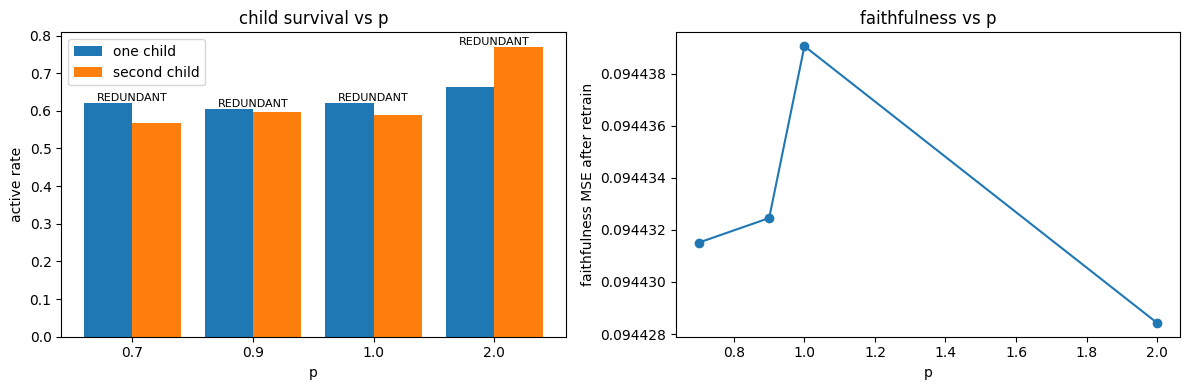

,p,outcome,overlap,faith_after,active,feat,conc,child_feats_served
0,0.7,REDUNDANT / smear,0.614670,0.094432,"[0.621, 0.567]","[28, 16]","[0.09, 0.07]","[23.9, 25.3]"
1,0.9,REDUNDANT / smear,0.623642,0.094432,"[0.606, 0.597]","[28, 16]","[0.09, 0.07]","[23.9, 25.3]"
2,1.0,REDUNDANT / smear,0.620746,0.094439,"[0.62, 0.589]","[28, 16]","[0.09, 0.07]","[23.7, 25.4]"
3,2.0,REDUNDANT / smear,0.728155,0.094428,"[0.664, 0.77]","[28, 16]","[0.09, 0.07]","[23.9, 25.3]"


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ps = [r["p"] for r in results]
c0 = [r["active"][0] for r in results]; c1 = [r["active"][1] for r in results]
x = np.arange(len(ps))
ax[0].bar(x - 0.2, c0, 0.4, label="one child"); ax[0].bar(x + 0.2, c1, 0.4, label="second child")
ax[0].set_xticks(x); ax[0].set_xticklabels(ps); ax[0].set_xlabel("p"); ax[0].set_ylabel("active rate")
ax[0].set_title("child survival vs p"); ax[0].legend()
for i, r in enumerate(results):
    ax[0].text(i, max(c0[i], c1[i]) + 0.005, r["outcome"].split()[0], ha="center", fontsize=8)
ax[1].plot(ps, [r["faith_after"] for r in results], "o-")
ax[1].set_xlabel("p"); ax[1].set_ylabel("faithfulness MSE after retrain"); ax[1].set_title("faithfulness vs p")
plt.tight_layout(); plt.show()

import pandas as pd
pd.DataFrame(results)

## 11. Other split-move variants 

In [12]:
# --- compare all split modes on the same component at the operating point ---
SPLIT_MODES = ["partition", "split_reader5050", "split_writer5050", "dupnoiseA", "clone", "dupnoiseB", "dummy"]
REC_P = 0.7 # From prev expriments it is proved to be the most effective p value
mode_results = []
for m in SPLIT_MODES:
    torch.manual_seed(7)               # same batches / masks / noise draws for every mode
    cm_m = copy.deepcopy(cm)
    child = split_component(cm_m, FEATURE_LAYER, SPLIT_COMP, mode=m)
    f_surg = faithfulness_mse(cm_m)    # exact modes: identical to the loaded value; dup family: ~1e-3
    pre, _, _ = analyze_children(cm_m, FEATURE_LAYER, [SPLIT_COMP, child], N_FEATURES, FEAT_P, float(nserve[SPLIT_COMP]))
    continue_train(cm_m, N_FEATURES, FEAT_P, steps=RETRAIN_STEPS, p_norm=REC_P,
                   freeze_keep=(FEATURE_LAYER, [SPLIT_COMP, child]) if FREEZE_OTHERS else None,
                   warmup_frac=MINIMALITY_WARMUP)
    rows, overlap, outcome = analyze_children(cm_m, FEATURE_LAYER, [SPLIT_COMP, child], N_FEATURES, FEAT_P, float(nserve[SPLIT_COMP]))
    mode_results.append(dict(mode=m, faith_surgery=f"{f_surg:.1e}",
                             pre_active=[round(r["active_rate"], 2) for r in pre],
                             active=[round(r["active_rate"], 2) for r in rows],
                             feat=[r["pref_feat"] for r in rows],
                             feats_served=[round(r["feats_served"], 1) for r in rows],
                             overlap=round(overlap, 2),
                             faith_final=f"{faithfulness_mse(cm_m):.1e}", outcome=outcome))
    print(mode_results[-1])

import pandas as pd
pd.DataFrame(mode_results)

{'mode': 'partition', 'faith_surgery': '1.0e-01', 'pre_active': [0.24, 0.2], 'active': [0.61, 0.57], 'feat': [28, 16], 'feats_served': [23.9, 25.2], 'overlap': 0.62, 'faith_final': '9.4e-02', 'outcome': 'REDUNDANT / smear'}
{'mode': 'split_reader5050', 'faith_surgery': '1.0e-01', 'pre_active': [0.18, 0.18], 'active': [0.58, 0.58], 'feat': [12, 16], 'feats_served': [23.8, 24.3], 'overlap': 0.63, 'faith_final': '9.4e-02', 'outcome': 'REDUNDANT / smear'}
{'mode': 'split_writer5050', 'faith_surgery': '1.0e-01', 'pre_active': [0.36, 0.36], 'active': [0.61, 0.64], 'feat': [12, 16], 'feats_served': [23.9, 24.0], 'overlap': 0.73, 'faith_final': '9.4e-02', 'outcome': 'REDUNDANT / smear'}
{'mode': 'dupnoiseA', 'faith_surgery': '1.1e-01', 'pre_active': [0.37, 0.37], 'active': [0.6, 0.61], 'feat': [16, 12], 'feats_served': [23.6, 22.8], 'overlap': 0.65, 'faith_final': '9.4e-02', 'outcome': 'REDUNDANT / smear'}
{'mode': 'clone', 'faith_surgery': '1.1e-01', 'pre_active': [0.37, 0.37], 'active': [0.5

,mode,faith_surgery,pre_active,active,feat,feats_served,overlap,faith_final,outcome
0,partition,1.0e-01,"[0.24, 0.2]","[0.61, 0.57]","[28, 16]","[23.9, 25.2]",0.62,9.4e-02,REDUNDANT / smear
1,split_reader5050,1.0e-01,"[0.18, 0.18]","[0.58, 0.58]","[12, 16]","[23.8, 24.3]",0.63,9.4e-02,REDUNDANT / smear
2,split_writer5050,1.0e-01,"[0.36, 0.36]","[0.61, 0.64]","[12, 16]","[23.9, 24.0]",0.73,9.4e-02,REDUNDANT / smear
3,dupnoiseA,1.1e-01,"[0.37, 0.37]","[0.6, 0.61]","[16, 12]","[23.6, 22.8]",0.65,9.4e-02,REDUNDANT / smear
4,clone,1.1e-01,"[0.37, 0.37]","[0.59, 0.68]","[11, 12]","[23.6, 24.0]",0.69,9.4e-02,REDUNDANT / smear
5,dupnoiseB,1.1e-01,"[0.36, 0.36]","[0.6, 0.56]","[11, 12]","[23.5, 23.0]",0.64,9.4e-02,REDUNDANT / smear
6,dummy,1.0e-01,"[0.38, 0.07]","[0.48, 0.52]","[12, 6]","[23.9, 24.1]",0.50,9.4e-02,REDUNDANT / smear




Seven ways to add the new slot, differing along two axes: **is the summed weight preserved
exactly** (surgery leaves faithfulness untouched — the `faith_surgery` column must equal the
loaded value, which doubles as a regression test), and **do the children's READERS differ**
(the only thing the gates see, hence the only lever per-input specialization can use).

| mode | exact? | readers differ? | measured on this checkpoint (comp 5 & comp 19) |
|---|---|---|---|
| `partition` | yes | disjoint supports | only mode with feature reduction (sheds a ~8–9-feat specialist) |
| `split_reader5050` | yes | same direction ± noise | partial differentiation at best; parent regrows |
| `split_writer5050` | yes | identical | redundant twins, overlap ~0.5–0.6 |
| `dupnoiseA` | no (2× contribution) | ± reader noise | ≈ clone: 0.1·RMS noise gives no measurable edge |
| `clone` | no (2× contribution) | identical (only mask draws differ) | redundant twins |
| `dupnoiseB` | no (2× contribution) | identical (noise on writer) | redundant twins — writer noise is not the lever |
| `dummy` | no (small) | fresh random | child dies before role transfer (needs gentler minimality) |

The ± antisymmetric noise in the exact modes is what makes them exact: `(x/2+d)+(x/2−d)=x`,
so the delta only breaks the child-permutation symmetry. A one-sided `+d` would leak into the
sum and pay a faithfulness cost for nothing. Noise scales with the parent tensor's RMS.
Implementation note: the parent's reader/writer are **cloned before** the in-place slot write —
`A[:, src]` is a view, and building the sibling from the mutated view silently breaks exactness.

## 12. Iterative splitting

We **iterate**: each round, re-scan the LIVE components, pick the **most polysemantic** one (largest `feats_served`), split it, retrain at the operating point (`coeff=2e-5`, `p=0.7`, freeze-others + warmup), and
repeat — stopping when the worst live component is ~monosemantic (`feats_served <= MONO_THRESH`)
or after `REC_MAX_ROUNDS`. The split `mode` is an **explicit argument recorded in every history
row**, so partition and duplicate runs can never be confused after the fact.

The loop is **greedy / breadth-first**: it always attacks the worst offender, so it spreads across
components before coming back to split the children. Reaching full monosemanticity for 40 features
needs ~27 splits (13 live → ~40); `REC_MAX_ROUNDS` caps it for a tractable run.

In [13]:
REC_COEFF      = 2e-5     # highest coeff below your death threshold (from the sweep)
REC_P          = 0.7      # most concave surviving p -> sharpest carve
REC_STEPS      = 1500     # retrain steps per split
REC_MAX_ROUNDS = 50       # cap; a true safety limit now that success/exhaustion exits can fire
MONO_THRESH    = 1.5      # ~monosemantic under the AMPLITUDE convention: the cleanly mono
                          # components (14, 18: conc ~0.7) read as feats_served=2.0, so the old
                          # 1.5 was unreachable and the success exit could never fire
SPLIT_MIN_ACTIVE  = 0.1   # selection gate: only components firing on >10% of inputs are split
                          # candidates -- near-dead smear has noise-inflated feats_served (the
                          # ghost-ratio artifact) and would otherwise capture the argmax forever
REPORT_MIN_ACTIVE = 0.1   # final-report filter: ghost debris above ALIVE_THRESH but below this
                          # is listed separately, not mixed into the headline feats_served
SPLIT_MODE = "partition"

def iterative_split(cm, feature_layer=FEATURE_LAYER, mode=SPLIT_MODE, coeff=REC_COEFF, p=REC_P,
                    steps=REC_STEPS, max_rounds=REC_MAX_ROUNDS, mono_thresh=MONO_THRESH,
                    warmup=MINIMALITY_WARMUP, freeze=False, log=True, plot=True):
    """Greedy loop: split the most polysemantic HEALTHY component, retrain, repeat.
    Selection is gated (active_rate > SPLIT_MIN_ACTIVE) and failed lineages are blacklisted
    (parent AND child banned after a non-carve outcome), so the loop cannot rathole on ghosts
    or stubborn cores. Exits: (1) success -- every candidate ~monosemantic; (2) exhaustion --
    every candidate dead; (3) max_rounds safety cap. `mode` is explicit and recorded."""
    cm = copy.deepcopy(cm)            # work on a copy so the loaded model is preserved
    history, progress = [], []
   
    stop_reason = f"max_rounds cap ({max_rounds}) reached"
    for rnd in range(max_rounds):
        conc, nserve = feature_concentration(cm, feature_layer)
        active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
        live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
        n_live = int(live.sum())
        live_served = [float(nserve[i]) for i in live_idx]
        progress.append(dict(round=rnd, n_live=n_live,                 # population snapshot
                             mean_feats=sum(live_served) / n_live,     # BEFORE this round's splits
                             max_feats=max(live_served)))
        # candidates: live, healthy enough to trust feats_served, and not blacklisted
        cand = [int(i) for i in live_idx
                if float(active_rate[i]) > SPLIT_MIN_ACTIVE]
        if not cand:
            stop_reason = (f"no candidates left: {n_live} live")
            break
        worst = max(cand, key=lambda i: float(nserve[i]))    # most polysemantic candidate
        worst_served = float(nserve[worst])
        if worst_served <= mono_thresh:
            stop_reason = (f"SUCCESS: all {len(cand)} candidates ~monosemantic "
                           f"(max feats={worst_served:.1f} <= {mono_thresh})")
            break

        child = split_component(cm, feature_layer, worst, mode=mode)
        continue_train(cm, N_FEATURES, FEAT_P, steps=steps, p_norm=p, imp_coeff=coeff,
                       freeze_keep=(feature_layer, [worst, child]) if freeze else None,
                       warmup_frac=warmup, monitor=None)
        
        rows, overlap, outcome = analyze_children(cm, feature_layer, [worst, child],
                                                  N_FEATURES, FEAT_P, worst_served)
        a = [round(r["active_rate"], 3) for r in rows]
        # feats from the SAME analysis as the outcome; nan for a dead child rather than the
        # ghost-ratio number (a dead component's footprint participation ratio is noise)
        fs = [round(r["feats_served"], 1) if r["active_rate"] > ALIVE_THRESH else float("nan")
              for r in rows]
        alive = min(r["active_rate"] for r in rows) > ALIVE_THRESH   # same threshold as everywhere
             # retire the whole lineage
        history.append(dict(round=rnd, mode=mode, split=worst, parent_feats=round(worst_served, 1),
                            child_feats=fs, active=a, overlap=round(overlap, 2),
                            alive=alive, outcome=outcome, n_live_before=n_live))
        if log: print(f"round {rnd}: split comp {worst} (feats {worst_served:.1f}) -> children {fs} "
                      f"active={a} overlap={overlap:.2f} alive={alive} {outcome} | live_before={n_live}")
    # final state: report healthy components and ghost debris separately
    conc, nserve = feature_concentration(cm, feature_layer)
    active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
    live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
    healthy = [i for i in live_idx.tolist() if float(active_rate[i]) > REPORT_MIN_ACTIVE]
    ghosts  = [i for i in live_idx.tolist() if float(active_rate[i]) <= REPORT_MIN_ACTIVE]
    live_feats = sorted([float(nserve[i]) for i in healthy], reverse=True)
    if log:
        print(f"\nSTOP: {stop_reason}")
        print(f"FINAL: {len(healthy)} healthy live components"
              f" (+{len(ghosts)} ghost/near-dead excluded from summary: {ghosts})")
        print(f"  feats_served = {[round(f,1) for f in live_feats]}")
        print(f"  {sum(1 for f in live_feats if f <= mono_thresh)}/{len(live_feats)} "
              f"~monosemantic (<= {mono_thresh})")
        
    if plot and progress:
        rounds = [q["round"] for q in progress]
        fig, ax1 = plt.subplots(figsize=(9, 3.5))
        ax1.plot(rounds, [q["mean_feats"] for q in progress], "o-", label="mean feats/component")
        ax1.plot(rounds, [q["max_feats"] for q in progress], "s--", alpha=0.6, label="max (worst component)")
        ax1.axhline(mono_thresh, color="r", ls=":", label=f"mono threshold ({mono_thresh})")
        ax1.set_xlabel("round"); ax1.set_ylabel("features served (amplitude PR)")
        ax1.legend(loc="upper right")
        ax2 = ax1.twinx()
        ax2.plot(rounds, [q["n_live"] for q in progress], color="gray", alpha=0.4)
        ax2.set_ylabel("live components", color="gray")
        ax1.set_title("population polysemanticity per round")
        plt.tight_layout(); plt.show()
    return cm, history, live_feats, progress

round 0: split comp 0 (feats 24.3) -> children [23.8, 26.0] active=[0.596, 0.596] overlap=0.60 alive=True REDUNDANT / smear | live_before=2
round 1: split comp 2 (feats 26.0) -> children [25.1, 23.9] active=[0.646, 0.606] overlap=0.62 alive=True REDUNDANT / smear | live_before=3
round 2: split comp 0 (feats 25.4) -> children [25.8, 23.7] active=[0.708, 0.57] overlap=0.65 alive=True REDUNDANT / smear | live_before=4
round 3: split comp 0 (feats 25.8) -> children [24.7, 23.8] active=[0.614, 0.608] overlap=0.60 alive=True REDUNDANT / smear | live_before=5
round 4: split comp 4 (feats 26.3) -> children [26.8, 25.7] active=[0.655, 0.622] overlap=0.65 alive=True REDUNDANT / smear | live_before=6
round 5: split comp 4 (feats 26.8) -> children [25.3, 27.1] active=[0.615, 0.638] overlap=0.65 alive=True REDUNDANT / smear | live_before=7
round 6: split comp 7 (feats 27.1) -> children [24.4, 30.0] active=[0.538, 0.634] overlap=0.58 alive=True REDUNDANT / smear | live_before=8
round 7: split comp 8

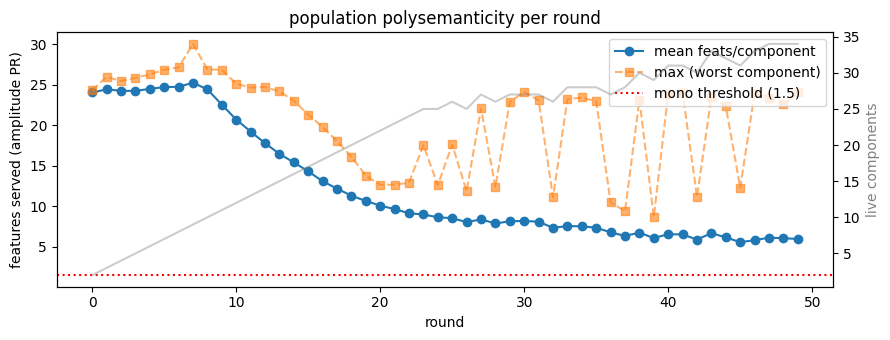

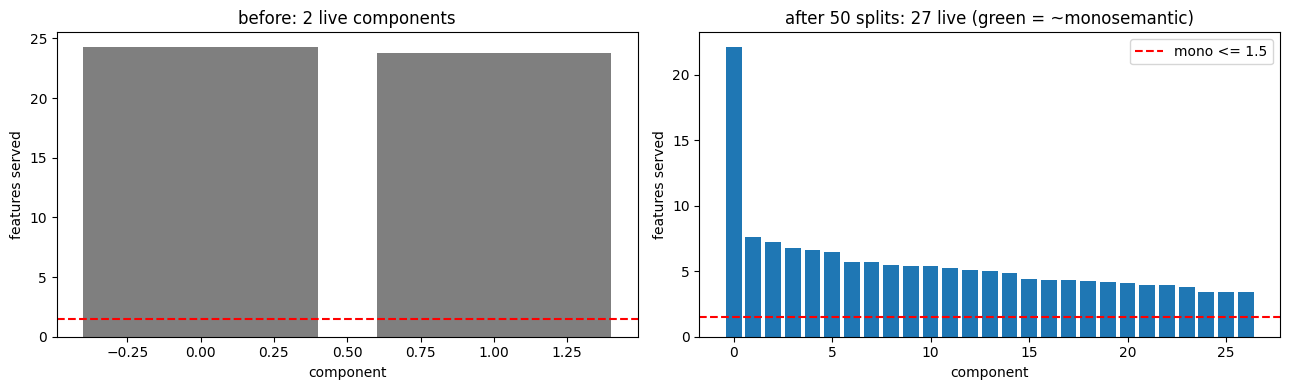

In [14]:
cm_rec1, rec_history1, rec_live_feats1, progress1 = iterative_split(cm, mode=SPLIT_MODE)

# feats_served of the live components before vs after recursion
_, nserve0 = feature_concentration(cm, FEATURE_LAYER)
ar0, wn0 = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
before = sorted([float(nserve0[i]) for i in torch.nonzero(live_mask(ar0, wn0)).flatten()], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(before)), before, color="tab:gray"); ax[0].axhline(MONO_THRESH, color="r", ls="--")
ax[0].set_title(f"before: {len(before)} live components"); ax[0].set_xlabel("component"); ax[0].set_ylabel("features served")
colors = ["tab:green" if f <= MONO_THRESH else "tab:blue" for f in rec_live_feats1]
ax[1].bar(range(len(rec_live_feats1)), rec_live_feats1, color=colors); ax[1].axhline(MONO_THRESH, color="r", ls="--", label=f"mono <= {MONO_THRESH}")
ax[1].set_title(f"after {len(rec_history1)} splits: {len(rec_live_feats1)} live (green = ~monosemantic)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("features served"); ax[1].legend()
plt.tight_layout(); plt.show()

# import pandas as pd
# pd.DataFrame(rec_history1)

## 12.B. Iterative batch splitting with fixed batch_size=2

In [15]:
REC_COEFF      = 2e-5     # highest coeff below your death threshold (from the sweep)
REC_P          = 0.7      # most concave surviving p -> sharpest carve
REC_STEPS      = 1500     # retrain steps per ROUND (one shared retrain for the whole batch)
REC_MAX_ROUNDS = 50       # cap; a true safety limit now that the success exit can fire
MONO_THRESH    = 1.5      # ~monosemantic under the AMPLITUDE convention: the cleanly mono
                          # components (14, 18: conc ~0.7) read as feats_served=2.0, so the old
                          # 1.5 was unreachable and the success exit could never fire
SPLIT_MODE = "partition"
BATCH_SIZE = 2            # components split per round (1 = old sequential loop)

def batch_iterative_split(cm, feature_layer=FEATURE_LAYER, mode=SPLIT_MODE, coeff=REC_COEFF, p=REC_P,
                    steps=REC_STEPS, max_rounds=REC_MAX_ROUNDS, batch_size=BATCH_SIZE,
                    mono_thresh=MONO_THRESH, warmup=MINIMALITY_WARMUP, freeze=False,
                    log=True, plot=True):
    """Greedy loop with BATCHING: each round, split the `batch_size` most polysemantic LIVE
    components in ONE surgery and retrain ONCE for the whole batch (freeze_keep covers all
    touched parent+child slots). batch_size=1 reproduces the old sequential loop exactly.
    Selection is UNGATED (grow-from-small regime: correctly carved components fire rarely,
    so live_mask is the only activity filter). Exits: (1) success -- every live component
    ~monosemantic; (2) no live components; (3) max_rounds safety cap.
    `mode` is explicit and recorded."""
    cm = copy.deepcopy(cm)            # work on a copy so the loaded model is preserved
    history, progress = [], []

    stop_reason = f"max_rounds cap ({max_rounds}) reached"
    for rnd in range(max_rounds):
        conc, nserve = feature_concentration(cm, feature_layer)
        active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
        live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
        n_live = int(live.sum())
        if n_live == 0:
            stop_reason = "no live components left"
            break
        live_served = [float(nserve[i]) for i in live_idx]
        progress.append(dict(round=rnd, n_live=n_live,                 # population snapshot
                             mean_feats=sum(live_served) / n_live,     # BEFORE this round's splits
                             max_feats=max(live_served)))
        # eligible: LIVE components still above the mono threshold, most polysemantic first
        eligible = sorted([int(i) for i in live_idx if float(nserve[i]) > mono_thresh],
                          key=lambda i: float(nserve[i]), reverse=True)
        if not eligible:
            stop_reason = (f"SUCCESS: all {n_live} live components ~monosemantic "
                           f"(max feats={max(live_served):.1f} <= {mono_thresh})")
            break
        parents = eligible[:int(batch_size)]
        parent_feats = [float(nserve[s]) for s in parents]

        # one surgery for the whole batch, then ONE shared retrain for all touched slots
        children = split_component(cm, feature_layer, parents if len(parents) > 1 else parents[0],
                                   mode=mode)
        children = [children] if isinstance(children, int) else list(children)
        touched = parents + children
        continue_train(cm, N_FEATURES, FEAT_P, steps=steps, p_norm=p, imp_coeff=coeff,
                       freeze_keep=(feature_layer, touched) if freeze else None,
                       warmup_frac=warmup, monitor=None)

        # per-pair analysis: feats from the SAME analysis as the outcome; nan for a dead child
        # rather than the ghost-ratio number (a dead component's footprint PR is noise)
        for s, c, pf in zip(parents, children, parent_feats):
            rows, overlap, outcome = analyze_children(cm, feature_layer, [s, c],
                                                      N_FEATURES, FEAT_P, pf)
            a = [round(r["active_rate"], 3) for r in rows]
            fs = [round(r["feats_served"], 1) if r["active_rate"] > ALIVE_THRESH else float("nan")
                  for r in rows]
            alive = min(r["active_rate"] for r in rows) > ALIVE_THRESH   # same threshold as everywhere
            history.append(dict(round=rnd, mode=mode, split=s, parent_feats=round(pf, 1),
                                child_feats=fs, active=a, overlap=round(overlap, 2),
                                alive=alive, outcome=outcome, n_live_before=n_live,
                                batch=len(parents)))
            if log: print(f"round {rnd}: split comp {s} (feats {pf:.1f}) -> children {fs} "
                          f"active={a} overlap={overlap:.2f} alive={alive} {outcome} "
                          f"| live_before={n_live} batch={len(parents)}")
    # final state: report ALL live components (no report-side gate)
    conc, nserve = feature_concentration(cm, feature_layer)
    active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
    live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
    live_feats = sorted([float(nserve[i]) for i in live_idx], reverse=True)
    if live_feats:                      # append the end point so the plot includes it
        progress.append(dict(round=len(progress), n_live=len(live_feats),
                             mean_feats=sum(live_feats) / len(live_feats),
                             max_feats=live_feats[0]))
    if log:
        print(f"\nSTOP: {stop_reason}")
        print(f"FINAL: {int(live.sum())} live components / {int(nserve.numel())} slots")
        print(f"  feats_served = {[round(f,1) for f in live_feats]}")
        print(f"  {sum(1 for f in live_feats if f <= mono_thresh)}/{len(live_feats)} "
              f"~monosemantic (<= {mono_thresh})")

    if plot and progress:
        rounds = [q["round"] for q in progress]
        fig, ax1 = plt.subplots(figsize=(9, 3.5))
        ax1.plot(rounds, [q["mean_feats"] for q in progress], "o-", label="mean feats/component")
        ax1.plot(rounds, [q["max_feats"] for q in progress], "s--", alpha=0.6, label="max (worst component)")
        ax1.axhline(mono_thresh, color="r", ls=":", label=f"mono threshold ({mono_thresh})")
        ax1.set_xlabel("round"); ax1.set_ylabel("features served (amplitude PR)")
        ax1.legend(loc="upper right")
        ax2 = ax1.twinx()
        ax2.plot(rounds, [q["n_live"] for q in progress], color="gray", alpha=0.4)
        ax2.set_ylabel("live components", color="gray")
        ax1.set_title("population polysemanticity per round")
        plt.tight_layout(); plt.show()
    return cm, history, live_feats, progress

round 0: split comp 0 (feats 24.3) -> children [23.1, 25.2] active=[0.604, 0.571] overlap=0.59 alive=True REDUNDANT / smear | live_before=2 batch=2
round 0: split comp 1 (feats 23.8) -> children [25.3, 25.7] active=[0.665, 0.656] overlap=0.69 alive=True REDUNDANT / smear | live_before=2 batch=2
round 1: split comp 3 (feats 25.7) -> children [26.6, 29.2] active=[0.698, 0.716] overlap=0.76 alive=True REDUNDANT / smear | live_before=4 batch=2
round 1: split comp 1 (feats 25.3) -> children [26.9, 26.2] active=[0.655, 0.651] overlap=0.67 alive=True REDUNDANT / smear | live_before=4 batch=2
round 2: split comp 4 (feats 29.2) -> children [27.2, 24.5] active=[0.666, 0.568] overlap=0.62 alive=True REDUNDANT / smear | live_before=6 batch=2
round 2: split comp 1 (feats 26.9) -> children [28.2, 28.1] active=[0.663, 0.649] overlap=0.67 alive=True REDUNDANT / smear | live_before=6 batch=2
round 3: split comp 1 (feats 28.2) -> children [25.4, 27.1] active=[0.594, 0.601] overlap=0.61 alive=True REDUND

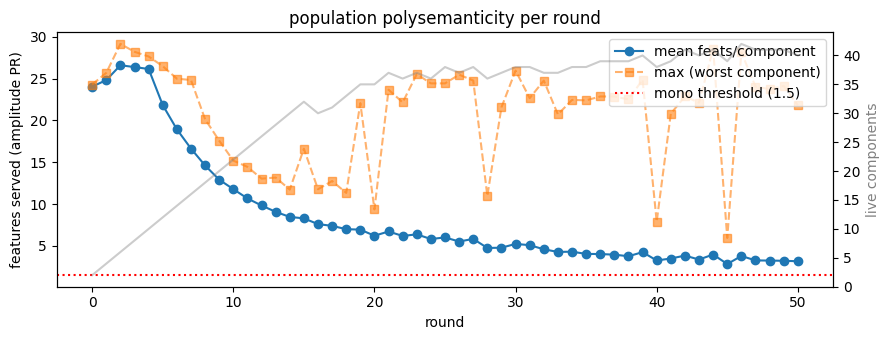

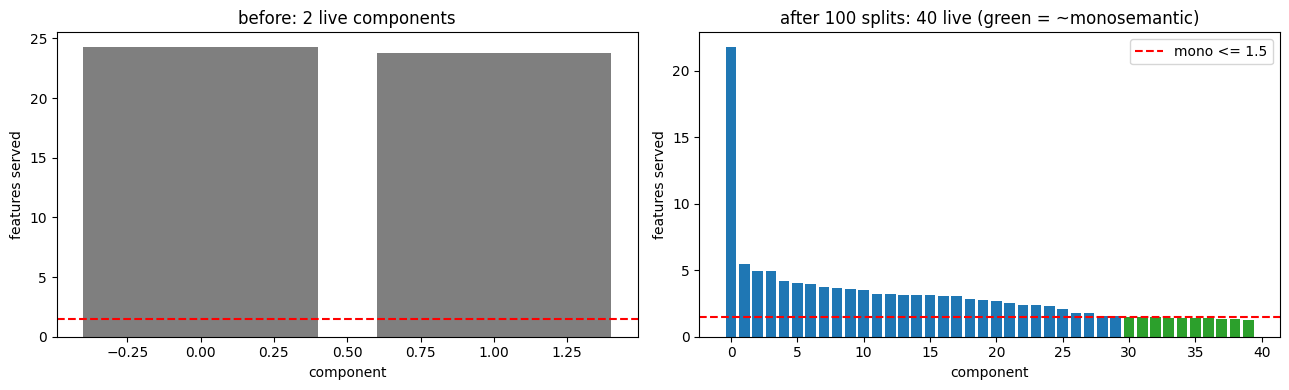

In [16]:
cm_rec2, rec_history2, rec_live_feats2, progress2 = batch_iterative_split(cm, mode=SPLIT_MODE)

# feats_served of the live components before vs after recursion
_, nserve0 = feature_concentration(cm, FEATURE_LAYER)
ar0, wn0 = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
before = sorted([float(nserve0[i]) for i in torch.nonzero(live_mask(ar0, wn0)).flatten()], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(before)), before, color="tab:gray"); ax[0].axhline(MONO_THRESH, color="r", ls="--")
ax[0].set_title(f"before: {len(before)} live components"); ax[0].set_xlabel("component"); ax[0].set_ylabel("features served")
colors = ["tab:green" if f <= MONO_THRESH else "tab:blue" for f in rec_live_feats2]
ax[1].bar(range(len(rec_live_feats2)), rec_live_feats2, color=colors); ax[1].axhline(MONO_THRESH, color="r", ls="--", label=f"mono <= {MONO_THRESH}")
ax[1].set_title(f"after {len(rec_history2)} splits: {len(rec_live_feats2)} live (green = ~monosemantic)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("features served"); ax[1].legend()
plt.tight_layout(); plt.show()

# import pandas as pd
# pd.DataFrame(rec_history2)

## 12.C.  Dynamic iterative batch splitting with fixed batch_size = num components

In [17]:
REC_COEFF      = 2e-5     # highest coeff below your death threshold (from the sweep)
REC_P          = 0.7      # most concave surviving p -> sharpest carve
REC_STEPS      = 2000     # retrain steps per ROUND (one shared retrain for the whole generation)
REC_MAX_ROUNDS = 20       # cap; with generational batching you need ~log2(C_final) rounds
MONO_THRESH    = 1.5      # ~monosemantic under the AMPLITUDE convention: the cleanly mono
                          # components (14, 18: conc ~0.7) read as feats_served=2.0, so the old
                          # 1.5 was unreachable and the success exit could never fire
SPLIT_MODE = "partition"
PRUNE_WNORM_FRAC = 0.05   # prune slots carrying < 5% of the max weight-norm: they contribute
                          # ~nothing to sum(A_c B_c), so deleting them barely moves faithfulness.
                          # Deliberately below the LIVE filter's 0.15 -- prune only clear garbage.

@torch.no_grad()
def prune_dead(cm, layer, keep_frac=PRUNE_WNORM_FRAC):
    """Physically delete near-zero-weight component slots (dead children, ghost debris) from
    `layer`. Returns (n_pruned, faith_delta). NOTE: component indices in this layer are NOT
    stable across a prune -- all bookkeeping in the loop re-derives indices fresh each round."""
    comp = module_maps(cm)[0][layer]; gate = module_maps(cm)[1][layer]
    wn = comp.A.data.norm(dim=0) * comp.B.data.norm(dim=1)
    keep = wn >= keep_frac * wn.max()
    n_pruned = int((~keep).sum())
    if n_pruned == 0:
        return 0, 0.0
    f_before = faithfulness_mse(cm)
    comp.A = nn.Parameter(comp.A.data[:, keep].clone())
    comp.B = nn.Parameter(comp.B.data[keep].clone())
    comp.C = int(keep.sum())
    if isinstance(gate, Gate):
        gate.weight = nn.Parameter(gate.weight.data[keep].clone())
        gate.bias   = nn.Parameter(gate.bias.data[keep].clone())
    else:
        for nm in ["mlp_in", "in_bias", "mlp_out", "out_bias"]:
            setattr(gate, nm, nn.Parameter(getattr(gate, nm).data[keep].clone()))
    return n_pruned, faithfulness_mse(cm) - f_before

def dynamic_batch_iterative_split(cm, feature_layer=FEATURE_LAYER, mode=SPLIT_MODE, coeff=REC_COEFF, p=REC_P,
                    steps=REC_STEPS, max_rounds=REC_MAX_ROUNDS, batch_size="auto",
                    mono_thresh=MONO_THRESH, warmup=MINIMALITY_WARMUP, freeze=False,
                    prune=True, log=True, plot=True):
    """Generational splitting with garbage collection. Each round:
      (1) PRUNE near-zero slots (dead children, ghost debris) so the tensors don't drag corpse
          columns through every forward pass -- indices are re-derived fresh after this;
      (2) split every LIVE component still above mono_thresh in ONE surgery -- already-mono
          components are ignored (excluded from splitting and, via freeze_keep, frozen during
          retrain), so the batch grows with the population (2 -> 4 -> 8 -> ...). Selection is
          UNGATED (grow-from-small regime: correctly carved components fire rarely, so
          live_mask is the only activity filter);
      (3) ONE shared retrain for the whole generation.
    batch_size="auto" takes all eligible components; an int caps the batch at the k most
    polysemantic; batch_size=1 is the old sequential loop.
    Exits: (1) success -- every live component ~monosemantic; (2) no live components;
    (3) max_rounds safety cap. `mode` is explicit and recorded."""
    cm = copy.deepcopy(cm)            # work on a copy so the loaded model is preserved
    history, progress = [], []

    stop_reason = f"max_rounds cap ({max_rounds}) reached"
    for rnd in range(max_rounds):
        # (1) garbage collection FIRST: after this, all indices below are fresh and valid
        n_pruned, faith_delta = prune_dead(cm, feature_layer) if prune else (0, 0.0)
        if log and n_pruned:
            print(f"round {rnd}: pruned {n_pruned} dead slot(s) "
                  f"(faithfulness delta {faith_delta:+.2e})")

        # (2) measure the post-prune population and pick this generation's parents
        conc, nserve = feature_concentration(cm, feature_layer)
        active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
        live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
        n_live = int(live.sum())
        if n_live == 0:
            stop_reason = "no live components left"
            break
        live_served = [float(nserve[i]) for i in live_idx]
        progress.append(dict(round=rnd, n_live=n_live,                 # population snapshot
                             mean_feats=sum(live_served) / n_live,     # BEFORE this round's splits
                             max_feats=max(live_served),
                             n_pruned=n_pruned))
        # eligible: LIVE components still above the mono threshold, most polysemantic first
        eligible = sorted([int(i) for i in live_idx if float(nserve[i]) > mono_thresh],
                          key=lambda i: float(nserve[i]), reverse=True)
        if not eligible:
            stop_reason = (f"SUCCESS: all {n_live} live components ~monosemantic "
                           f"(max feats={max(live_served):.1f} <= {mono_thresh})")
            break
        parents = eligible if batch_size == "auto" else eligible[:int(batch_size)]
        parent_feats = [float(nserve[s]) for s in parents]

        # (3) one surgery for the generation, then ONE shared retrain; freeze_keep restricts
        # training to combined parent+child slots, so mono components sit out automatically
        children = split_component(cm, feature_layer, parents if len(parents) > 1 else parents[0],
                                   mode=mode)
        children = [children] if isinstance(children, int) else list(children)
        combined = parents + children
        continue_train(cm, N_FEATURES, FEAT_P, steps=steps, p_norm=p, imp_coeff=coeff,
                       freeze_keep=(feature_layer, combined) if freeze else None,
                       warmup_frac=warmup, monitor=None)

        # per-pair analysis: feats from the SAME analysis as the outcome; nan for a dead child
        # rather than the ghost-ratio number (a dead component's footprint PR is noise)
        for s, c, pf in zip(parents, children, parent_feats):
            rows, overlap, outcome = analyze_children(cm, feature_layer, [s, c],
                                                      N_FEATURES, FEAT_P, pf)
            a = [round(r["active_rate"], 3) for r in rows]
            fs = [round(r["feats_served"], 1) if r["active_rate"] > ALIVE_THRESH else float("nan")
                  for r in rows]
            alive = min(r["active_rate"] for r in rows) > ALIVE_THRESH   # same threshold as everywhere
            history.append(dict(round=rnd, mode=mode, split=s, parent_feats=round(pf, 1),
                                child_feats=fs, active=a, overlap=round(overlap, 2),
                                alive=alive, outcome=outcome, n_live_before=n_live,
                                batch=len(parents), n_pruned=n_pruned))
            if log: print(f"round {rnd}: split comp {s} (feats {pf:.1f}) -> children {fs} "
                          f"active={a} overlap={overlap:.2f} alive={alive} {outcome} "
                          f"| live_before={n_live} batch={len(parents)}")
    # final state: one last garbage collection, then report ALL live components
    if prune:
        n_pruned, faith_delta = prune_dead(cm, feature_layer)
        if log and n_pruned:
            print(f"\nfinal prune: removed {n_pruned} dead slot(s) "
                  f"(faithfulness delta {faith_delta:+.2e})")
    conc, nserve = feature_concentration(cm, feature_layer)
    active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
    live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
    live_feats = sorted([float(nserve[i]) for i in live_idx], reverse=True)

    if live_feats:                      # append the end point so the plot includes it
        progress.append(dict(round=len(progress), n_live=len(live_feats),
                             mean_feats=sum(live_feats) / len(live_feats),
                             max_feats=live_feats[0], n_pruned=0))
    if log:
        print(f"\nSTOP: {stop_reason}")
        print(f"FINAL: {int(live.sum())} live components / {int(nserve.numel())} slots")
        print(f"  feats_served = {[round(f,1) for f in live_feats]}")
        print(f"  {sum(1 for f in live_feats if f <= mono_thresh)}/{len(live_feats)} "
              f"~monosemantic (<= {mono_thresh})")

    if plot and progress:
        rounds = [q["round"] for q in progress]
        fig, ax1 = plt.subplots(figsize=(9, 3.5))
        ax1.plot(rounds, [q["mean_feats"] for q in progress], "o-", label="mean feats/component")
        ax1.plot(rounds, [q["max_feats"] for q in progress], "s--", alpha=0.6, label="max (worst component)")
        ax1.axhline(mono_thresh, color="r", ls=":", label=f"mono threshold ({mono_thresh})")
        ax1.set_xlabel("round"); ax1.set_ylabel("features served (amplitude PR)")
        ax1.legend(loc="upper right")
        ax2 = ax1.twinx()
        ax2.plot(rounds, [q["n_live"] for q in progress], color="gray", alpha=0.4)
        ax2.set_ylabel("live components", color="gray")
        ax1.set_title("population polysemanticity per round")
        plt.tight_layout(); plt.show()
    return cm, history, live_feats, progress

round 0: split comp 0 (feats 24.3) -> children [23.6, 24.9] active=[0.623, 0.583] overlap=0.62 alive=True REDUNDANT / smear | live_before=2 batch=2
round 0: split comp 1 (feats 23.8) -> children [25.4, 25.7] active=[0.641, 0.625] overlap=0.67 alive=True REDUNDANT / smear | live_before=2 batch=2
round 1: split comp 3 (feats 25.7) -> children [25.7, 27.7] active=[0.629, 0.658] overlap=0.67 alive=True REDUNDANT / smear | live_before=4 batch=4
round 1: split comp 1 (feats 25.4) -> children [27.9, 26.1] active=[0.668, 0.656] overlap=0.70 alive=True REDUNDANT / smear | live_before=4 batch=4
round 1: split comp 2 (feats 24.9) -> children [24.6, 24.6] active=[0.645, 0.586] overlap=0.63 alive=True REDUNDANT / smear | live_before=4 batch=4
round 1: split comp 0 (feats 23.6) -> children [26.5, 30.0] active=[0.629, 0.677] overlap=0.69 alive=True REDUNDANT / smear | live_before=4 batch=4
round 2: split comp 7 (feats 30.0) -> children [19.8, 18.7] active=[0.456, 0.487] overlap=0.42 alive=True REDUND

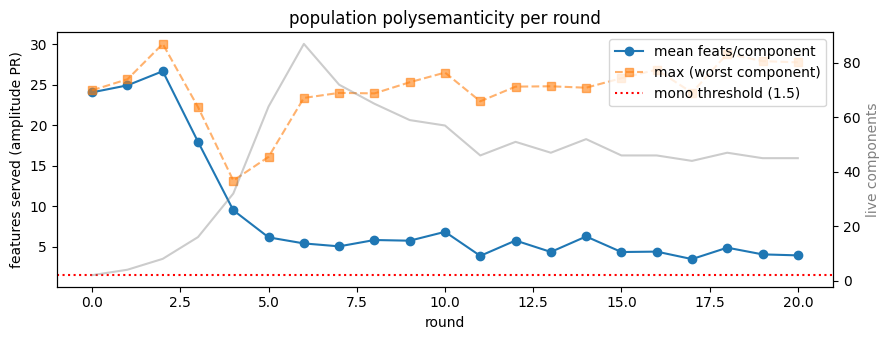

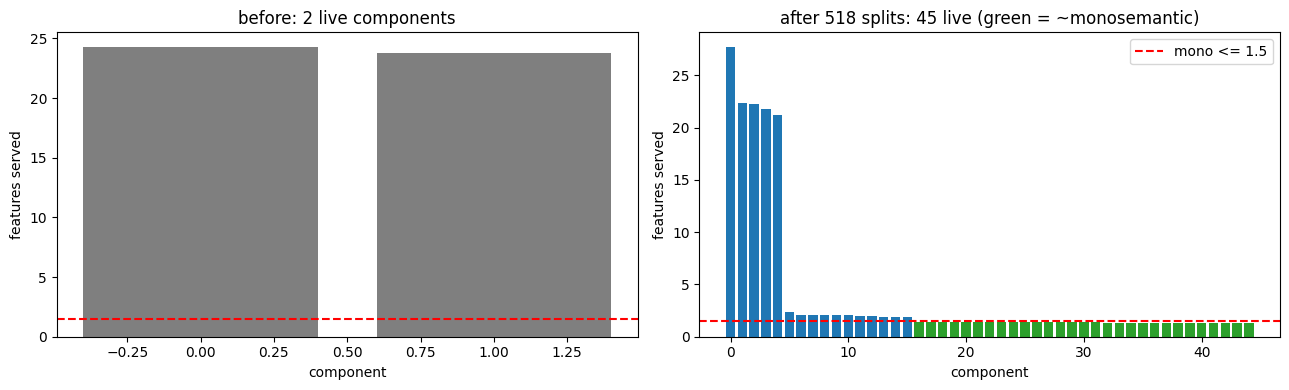

In [18]:
cm_rec3, rec_history3, rec_live_feats3, progress3 = dynamic_batch_iterative_split(cm, mode=SPLIT_MODE)

# feats_served of the live components before vs after recursion
_, nserve0 = feature_concentration(cm, FEATURE_LAYER)
ar0, wn0 = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
before = sorted([float(nserve0[i]) for i in torch.nonzero(live_mask(ar0, wn0)).flatten()], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(before)), before, color="tab:gray"); ax[0].axhline(MONO_THRESH, color="r", ls="--")
ax[0].set_title(f"before: {len(before)} live components"); ax[0].set_xlabel("component"); ax[0].set_ylabel("features served")
colors = ["tab:green" if f <= MONO_THRESH else "tab:blue" for f in rec_live_feats3]
ax[1].bar(range(len(rec_live_feats3)), rec_live_feats3, color=colors); ax[1].axhline(MONO_THRESH, color="r", ls="--", label=f"mono <= {MONO_THRESH}")
ax[1].set_title(f"after {len(rec_history3)} splits: {len(rec_live_feats3)} live (green = ~monosemantic)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("features served"); ax[1].legend()
plt.tight_layout(); plt.show()

# import pandas as pd
# pd.DataFrame(rec_history3)

In [19]:
@torch.no_grad()
def eval_alignment(cm, layer=FEATURE_LAYER, n=8192, tau=TAU):
    comp = module_maps(cm)[0][layer]
    A, B = comp.A.data, comp.B.data                      # (nf, C), (C, nh)
    W = cm.model.get_submodule(layer).weight.data        # (nh, nf): column i = feature i's direction
    active_rate, wnorm = component_stats(cm, layer, N_FEATURES, FEAT_P)
    live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()

    # --- 1. MMCS: cosine between each component's rank-1 piece and each ideal piece e_i (x) W[:,i]
    # factorizes: cos[c,i] = (|A[i,c]| / ||A[:,c]||) * |cos(B[c,:], W[:,i])|
    An = A / A.norm(dim=0, keepdim=True).clamp_min(1e-12)              # (nf, C)
    Bn = B / B.norm(dim=1, keepdim=True).clamp_min(1e-12)              # (C, nh)
    Wn = W / W.norm(dim=0, keepdim=True).clamp_min(1e-12)              # (nh, nf)
    cos = (An.abs() * (Bn @ Wn).abs().T)[:, live_idx]                  # (nf, n_live)
    per_comp_max, per_comp_match = cos.max(dim=0)        # purity: each component's best feature
    per_feat_max = cos[:, :].max(dim=1).values           # coverage: each feature's best component
    dup = torch.bincount(per_comp_match, minlength=N_FEATURES)         # components per feature
    print(f"MMCS (component purity):  mean={per_comp_max.mean():.3f}  min={per_comp_max.min():.3f}")
    print(f"MMCS (feature coverage):  mean={per_feat_max.mean():.3f}  min={per_feat_max.min():.3f}"
          f"  uncovered(<0.5): {(per_feat_max < 0.5).sum().item()}")
    print(f"redundancy: {int((dup > 1).sum())} features claimed by >1 component (max {int(dup.max())})")

    # --- 2a. functional alignment: gate/feature co-activation F1 (component c vs its matched feature)
    x = sample_batch(N_FEATURES, FEAT_P, bs=n)
    ci, _, _ = causal_importances(cm, x)
    g_on = ci[layer][:, live_idx] > tau                                # (n, n_live)
    f_on = x[:, per_comp_match] > 0                                    # (n, n_live) matched features
    tp = (g_on & f_on).float().sum(0)
    prec = tp / g_on.float().sum(0).clamp_min(1); rec = tp / f_on.float().sum(0).clamp_min(1)
    f1 = 2 * prec * rec / (prec + rec).clamp_min(1e-9)
    print(f"co-activation F1 vs matched feature: mean={f1.mean():.3f}  min={f1.min():.3f} "
          f"(precision {prec.mean():.3f}, recall {rec.mean():.3f})")

    # --- 2b. compositionality: does quality survive feature CO-activation?
    comps_map, _, _ = module_maps(cm)
    out = cm.forward_with_components(x, components=comps_map, masks=ci)
    tgt = cm.model(x)
    err = ((out - tgt) ** 2).mean(dim=-1)
    k_active = (x > 0).sum(dim=1)
    for k in range(0, int(k_active.max().item()) + 1):
        m = k_active == k
        if m.sum() > 20:
            print(f"  k={k} co-active features: recon MSE {err[m].mean():.2e}  (n={int(m.sum())})")
    return per_comp_max, per_feat_max, f1

def eval_efficiency(progress, steps_per_round=REC_STEPS):
    cost = 0; print("round  slots  live  mean_feats  cum_cost(step*slots)")
    for q in progress:
        cost += steps_per_round * q.get("n_slots", q["n_live"])
        print(f"{q['round']:5d}  {q.get('n_slots','-'):>5}  {q['n_live']:4d}  "
              f"{q['mean_feats']:9.2f}  {cost:.2e}")
    print(f"peak slots: {max(q.get('n_slots', q['n_live']) for q in progress)}")

In [20]:
print("Iterative splitting: ")
per_comp_max, per_feat_max, f1 = eval_alignment(cm_rec1)
print()
print("Batch iterative splitting with batch_size = 2:  ")
per_comp_max, per_feat_max, f1 = eval_alignment(cm_rec2)
print()
print("Dynamic batch iterative splitting with batch_size = num components:  ")
per_comp_max, per_feat_max, f1 = eval_alignment(cm_rec2)

Iterative splitting: 
MMCS (component purity):  mean=0.500  min=0.204
MMCS (feature coverage):  mean=0.472  min=0.254  uncovered(<0.5): 28
redundancy: 5 features claimed by >1 component (max 2)
co-activation F1 vs matched feature: mean=0.483  min=0.188 (precision 0.352, recall 0.885)
  k=0 co-active features: recon MSE 0.00e+00  (n=1056)
  k=1 co-active features: recon MSE 4.76e-03  (n=2275)
  k=2 co-active features: recon MSE 9.95e-03  (n=2288)
  k=3 co-active features: recon MSE 1.67e-02  (n=1510)
  k=4 co-active features: recon MSE 2.27e-02  (n=691)
  k=5 co-active features: recon MSE 3.24e-02  (n=280)
  k=6 co-active features: recon MSE 4.11e-02  (n=72)

Batch iterative splitting with batch_size = 2:  
MMCS (component purity):  mean=0.784  min=0.247
MMCS (feature coverage):  mean=0.776  min=0.280  uncovered(<0.5): 8
redundancy: 2 features claimed by >1 component (max 2)
co-activation F1 vs matched feature: mean=0.738  min=0.207 (precision 0.678, recall 0.897)
  k=0 co-active featur